<a href="https://colab.research.google.com/github/gllikhitha/ML_gll/blob/main/ML3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Design and implement supervised classification models using Logistic Regression, Linear Discriminant Analysis (LDA), and k-Nearest Neighbors (k-NN)


In [ ]:
import matplotlib.pyplot as plt

# Generate predictions
lr_predictions = lr_model.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(7,5))

plt.scatter(y_test, lr_predictions,
            color='blue',
            alpha=0.6,
            label='Linear Regression Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title("24eu02017 Actual vs. Predicted Median Housing Values")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()

NameError: name 'lr_model' is not defined

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
# Load dataset
iris_raw = load_iris()
X_iris = iris_raw.data
y_iris = iris_raw.target

# Standardize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (120, 4)
Test set shape: (30, 4)


### Subtask 1.2: Implementing Multinomial Logistic Regression
**Concept:** Design, train, and evaluate a multinomial Logistic Regression classifier to establish a parametric baseline model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize multinomial Logistic Regression classifier
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test data
lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")


Logistic Regression Test Accuracy: 93.33%


### Subtask 1.3: Implementing Linear Discriminant Analysis (LDA)
**Concept:** Train a Linear Discriminant Analysis (LDA) classifier to observe how linear decision boundaries maximize the separation between different classes.


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA classifier
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

# Predict on test data
lda_preds = lda_model.predict(X_test)
lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")


LDA Test Accuracy: 100.00%


Subtask 1.4: k-Nearest Neighbors (k-NN)
Concept: Train a k-NN classifier for classfication

In [ ]:
# Import k-NN classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the k-NN model
knn = KNeighborsClassifier()

# Train the model
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Evaluate the model
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("k-NN Classification Accuracy:", knn_accuracy)


k-NN Classification Accuracy: 0.9333333333333333


Subtask 1.5: Performance Comparison of Linear vs. Distance-Based Classifiers
Concept: Compare and analyze the test accuracy and structural differences of the Logistic Regression, LDA, and optimized k-NN models.

In [ ]:
# Assemble performance metrics
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

print("--- Performance Comparison on Iris Dataset ---")
print(comparison_df.to_string(index=False))

--- Performance Comparison on Iris Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          93.333333
Linear Discriminant Analysis (LDA)         100.000000
        k-Nearest Neighbors (k-NN)          93.333333


## Task 2: Develop classification models using Naïve Bayes and Support Vector Machines (SVM) for complex classification tasks
*Suggested Dataset: Sonar Dataset*


Subtask 2.1: Standard Scaling and High-Dimensional Data Splitting
Concept: Load the high-dimensional Sonar dataset, standardize the feature space, and perform a stratified split to prepare for binary classification.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


### Subtask 2.2: Implementing Gaussian Naïve Bayes
**Concept:** Train a Gaussian Naïve Bayes classifier to establish a probabilistic baseline under class-conditional independence assumptions.


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Initialize and train Gaussian Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_s, y_train_s)

# Predict and evaluate accuracy
nb_preds = nb_model.predict(X_test_s)
nb_accuracy = accuracy_score(y_test_s, nb_preds)

print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")


Gaussian Naïve Bayes Test Accuracy: 76.19%


### Subtask 2.3: Implementing Linear Support Vector Machines (SVM)
**Concept:** Train a Support Vector Machine (SVM) classifier with a linear kernel to construct a maximum-margin linear decision hyperplane.


In [ ]:
from sklearn.svm import SVC

# Initialize and train Support Vector Classifier with Linear Kernel
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_s, y_train_s)

# Predict and evaluate accuracy
linear_preds = svm_linear.predict(X_test_s)
linear_accuracy = accuracy_score(y_test_s, linear_preds)

print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")


Linear Kernel SVM Test Accuracy: 79.37%


In [ ]:
# Assemble performance metrics
sonar_comparison = pd.DataFrame({
    'Classifier': ['Gaussian Naïve Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'],
    'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy * 100]
})

print("--- Performance Comparison on High-Dimensional Sonar Dataset ---")
print(sonar_comparison.to_string(index=False))


--- Performance Comparison on High-Dimensional Sonar Dataset ---
                          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes (Probabilistic)          76.190476
  Linear Kernel SVM (Maximum-Margin)          79.365079


# Task 3: Analyze model performance using confusion matrix, precision, recall, F1-score, ROC analysis, and cross-validation techniques.

Subtask 3.1: Plotting the Confusion Matrix Heatmap
**Concept:** Generate a confusion matrix to visualize true positives, false positives, true negatives, and false negatives in your classification results.


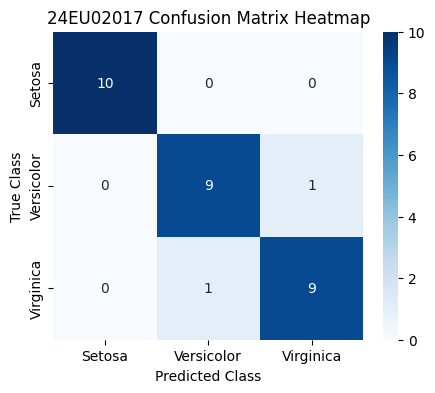

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix on Logistic Regression predictions
cm = confusion_matrix(y_test, lr_preds)

# Plot confusion matrix using a Seaborn heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("24EU02017 Confusion Matrix Heatmap")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

### Subtask 3.2: Precision, Recall, F1-Score, and Support Analysis
**Concept:** Generate a detailed classification report to compute and analyze continuous performance metrics for both target classes.


In [ ]:
from sklearn.metrics import classification_report

# Generate classification report for Logistic Regression
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



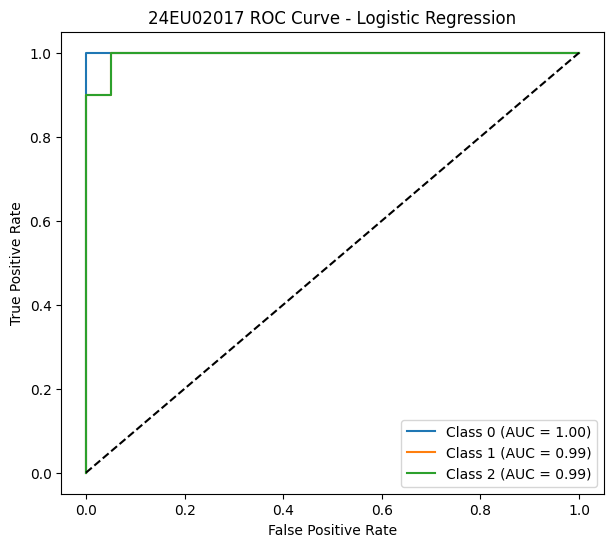

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert test labels to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities
y_score = lr_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("24EU02017 ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

## Cross Validation


In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=200)

# Perform 5-fold Cross Validation
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

# Display results
print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000

Mean Accuracy: 96.00%
Standard Deviation: 3.89%


# POST LAB

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Creating Titanic Dataset
data = {
    "Pclass":[3,1,3,1,3,2,1,3,2,1,3,1,2,3,1],
    "Sex":["male","female","female","female","male",
           "male","male","female","female","male",
           "male","female","male","female","female"],
    "Age":[22,38,26,35,35,28,54,2,27,14,20,58,40,18,50],
    "Fare":[7.25,71.28,7.92,53.10,8.05,
            13.00,51.86,21.07,11.13,30.07,
            8.45,26.55,16.00,7.90,80.00],
    "Embarked":["S","C","S","S","S",
                "Q","S","S","C","C",
                "Q","S","S","Q","C"],
    "Survived":[0,1,1,1,0,0,0,1,1,1,0,1,0,1,1]
}

df = pd.DataFrame(data)

print("Titanic Dataset")
print(df)

# Preprocessing
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

print("\nAfter Encoding")
print(df)

# Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("\nPredicted Values")
print(y_pred)

print("\nActual Values")
print(y_test.values)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Titanic Dataset
    Pclass     Sex  Age   Fare Embarked  Survived
0        3    male   22   7.25        S         0
1        1  female   38  71.28        C         1
2        3  female   26   7.92        S         1
3        1  female   35  53.10        S         1
4        3    male   35   8.05        S         0
5        2    male   28  13.00        Q         0
6        1    male   54  51.86        S         0
7        3  female    2  21.07        S         1
8        2  female   27  11.13        C         1
9        1    male   14  30.07        C         1
10       3    male   20   8.45        Q         0
11       1  female   58  26.55        S         1
12       2    male   40  16.00        S         0
13       3  female   18   7.90        Q         1
14       1  female   50  80.00        C         1

After Encoding
    Pclass  Sex  Age   Fare  Embarked  Survived
0        3    1   22   7.25         2         0
1        1    0   38  71.28         0         1
2        3    0   26   7